In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.9.1 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.0 pandas==1.5.3 scikit-learn==1.2.1 statsmodels==0.13.5 python-igraph==0.10.4 pynndescent==0.5.8


In [3]:
meta=pd.read_table('FromGitHub/Annotation_AHCA_alltissues_meta.data_84363_cell.txt', index_col=0)

In [4]:
meta

,orig.ident,nCount_RNA,nFeature_RNA,percent.mito,RNA_snn_res.orig,seurat_clusters,Color_of_tissues,Cell_type_in_each_tissue,tSNE_1,tSNE_2,Cell_type_in_merged_data
Bladder_cDNA_AAACCTGAGACACTAA-1,Bladder_cDNA,1152,610,0.078993,7,15,#aec7e8ff,Monocyte Bladder,-26.951585,4.300844,Monocyte
Bladder_cDNA_AAACCTGAGCATGGCA-1,Bladder_cDNA,3551,1415,0.056885,14,8,#aec7e8ff,Macrophage HLA-DPB1_high Bladder,-24.330971,16.842912,Macrophage C1QB
Bladder_cDNA_AAACCTGAGCTGAACG-1,Bladder_cDNA,1842,632,0.026602,4,1,#aec7e8ff,T Cell IL7R_high Bladder,14.544360,1.401564,T Cell IL7R
Bladder_cDNA_AAACCTGCAAGCTGGA-1,Bladder_cDNA,1599,890,0.026892,13,13,#aec7e8ff,Fibroblast APOD_high Bladder,-9.773034,3.715093,Fibroblast PTGDS
Bladder_cDNA_AAACCTGCATTACCTT-1,Bladder_cDNA,1347,613,0.054195,1,2,#aec7e8ff,T Cell CCL5_high Bladder,8.165036,-12.280489,T Cell XCL1
...,...,...,...,...,...,...,...,...,...,...,...
Trachea_cDNA_TTTGTCATCAGTTGAC-1,Trachea_cDNA,3334,1461,0.042292,13,36,#d62790ff,B Cell Trachea,23.177555,-1.750147,B Cell MS4A1
Trachea_cDNA_TTTGTCATCATCATTC-1,Trachea_cDNA,6634,2271,0.061200,7,8,#d62790ff,Macrophage/Monocyte Trachea,-23.203405,12.493359,Macrophage C1QB
Trachea_cDNA_TTTGTCATCTACGAGT-1,Trachea_cDNA,2255,769,0.211973,13,2,#d62790ff,B Cell Trachea,0.464167,-6.087522,T Cell XCL1
Trachea_cDNA_TTTGTCATCTCTAGGA-1,Trachea_cDNA,1568,832,0.055485,0,21,#d62790ff,CD8 T Cell CCL5_high Trachea,18.134920,-20.448501,T Cell CCL5


In [5]:
adata=sc.read_h5ad('Cumulus_VersionB/Merged.unknown-rna.h5ad')

In [6]:
adata

AnnData object with n_obs × n_vars = 160096 × 41312
    obs: 'n_genes', 'n_counts', 'Channel', 'percent_mito', 'scale', 'louvain_labels'
    var: 'featureid', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'mean', 'var', 'hvf_loess', 'hvf_rank'
    uns: 'Channels', 'PCs', 'W_pca', 'df_qcplot', 'genome', 'louvain_resolution', 'modality', 'norm_count', 'pca', 'pca_features', 'pca_knn_distances', 'pca_knn_indices', 'scale.data', 'scale.data.rownames', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std'
    obsm: 'X_pca', 'X_umap'
    varm: 'de_res'

In [7]:
adata.raw.X

<160096x41312 sparse matrix of type '<class 'numpy.float32'>'
	with 137236556 stored elements in Compressed Sparse Row format>

In [8]:
adata.obs=adata.obs.replace('Small_intestine', 'Small.intestine')
adata.obs=adata.obs.replace('Common_bile_duct', 'Common.bile.duct')
adata.obs=adata.obs.replace('Lymph_node', 'Lymph.node')


In [9]:
adata.obs.Channel.value_counts()

Heart               23251
Muscle              18434
Small.intestine     16042
Esophagus           14364
Bladder             13644
Skin                12016
Trachea             11825
Rectum              10554
Lymph.node          10068
Stomach              8807
Spleen               5870
Common.bile.duct     4487
Liver                4472
Marrow               4207
Blood                2055
Name: Channel, dtype: int64

In [10]:
adata.obs

,n_genes,n_counts,Channel,percent_mito,scale,louvain_labels
barcodekey,,,,,,
Bladder-AAACCTGAGACACTAA,602,1134,Bladder,8.730159,88.183422,4
Bladder-AAACCTGAGATAGGAG,104,110,Bladder,0.000000,909.090909,8
Bladder-AAACCTGAGCATGGCA,1391,3499,Bladder,6.401829,28.661508,4
Bladder-AAACCTGAGCTGAACG,616,1792,Bladder,2.734375,55.834729,2
Bladder-AAACCTGAGGCGCTCT,456,810,Bladder,3.333333,123.609394,2
...,...,...,...,...,...,...
Trachea-TTTGTCATCATCATTC,2242,6584,Trachea,7.351154,15.202189,4
Trachea-TTTGTCATCTACGAGT,750,2330,Trachea,25.708155,42.918455,3
Trachea-TTTGTCATCTCTAGGA,810,1542,Trachea,7.457847,64.935065,5


In [11]:
adata.obs['cell_id']=adata.obs.index.str[-16:]

In [12]:
adata.obs['to_match']=adata.obs['Channel'].astype(str)+'_cDNA_' +adata.obs['cell_id'].astype(str)+'-1'

In [13]:
#check number of matching cells
cells_to_keep = meta.index.intersection(adata.obs.to_match)
cells_to_keep

Index(['Bladder_cDNA_AAACCTGAGACACTAA-1', 'Bladder_cDNA_AAACCTGAGCATGGCA-1',
       'Bladder_cDNA_AAACCTGAGCTGAACG-1', 'Bladder_cDNA_AAACCTGCAAGCTGGA-1',
       'Bladder_cDNA_AAACCTGCATTACCTT-1', 'Bladder_cDNA_AAACCTGGTCTCTCGT-1',
       'Bladder_cDNA_AAACCTGGTTTCGCTC-1', 'Bladder_cDNA_AAACCTGTCACTTCAT-1',
       'Bladder_cDNA_AAACCTGTCCCGGATG-1', 'Bladder_cDNA_AAACCTGTCCGCGTTT-1',
       ...
       'Trachea_cDNA_TTTGTCAGTATGGTTC-1', 'Trachea_cDNA_TTTGTCAGTGGGTATG-1',
       'Trachea_cDNA_TTTGTCAGTTCTCATT-1', 'Trachea_cDNA_TTTGTCATCACCCTCA-1',
       'Trachea_cDNA_TTTGTCATCAGCTTAG-1', 'Trachea_cDNA_TTTGTCATCAGTTGAC-1',
       'Trachea_cDNA_TTTGTCATCATCATTC-1', 'Trachea_cDNA_TTTGTCATCTACGAGT-1',
       'Trachea_cDNA_TTTGTCATCTCTAGGA-1', 'Trachea_cDNA_TTTGTCATCTGCGACG-1'],
      dtype='object', length=84363)

In [14]:
adata.obs.index=adata.obs.to_match
adata.obs

,n_genes,n_counts,Channel,percent_mito,scale,louvain_labels,cell_id,to_match
to_match,,,,,,,,
Bladder_cDNA_AAACCTGAGACACTAA-1,602,1134,Bladder,8.730159,88.183422,4,AAACCTGAGACACTAA,Bladder_cDNA_AAACCTGAGACACTAA-1
Bladder_cDNA_AAACCTGAGATAGGAG-1,104,110,Bladder,0.000000,909.090909,8,AAACCTGAGATAGGAG,Bladder_cDNA_AAACCTGAGATAGGAG-1
Bladder_cDNA_AAACCTGAGCATGGCA-1,1391,3499,Bladder,6.401829,28.661508,4,AAACCTGAGCATGGCA,Bladder_cDNA_AAACCTGAGCATGGCA-1
Bladder_cDNA_AAACCTGAGCTGAACG-1,616,1792,Bladder,2.734375,55.834729,2,AAACCTGAGCTGAACG,Bladder_cDNA_AAACCTGAGCTGAACG-1
Bladder_cDNA_AAACCTGAGGCGCTCT-1,456,810,Bladder,3.333333,123.609394,2,AAACCTGAGGCGCTCT,Bladder_cDNA_AAACCTGAGGCGCTCT-1
...,...,...,...,...,...,...,...,...
Trachea_cDNA_TTTGTCATCATCATTC-1,2242,6584,Trachea,7.351154,15.202189,4,TTTGTCATCATCATTC,Trachea_cDNA_TTTGTCATCATCATTC-1
Trachea_cDNA_TTTGTCATCTACGAGT-1,750,2330,Trachea,25.708155,42.918455,3,TTTGTCATCTACGAGT,Trachea_cDNA_TTTGTCATCTACGAGT-1
Trachea_cDNA_TTTGTCATCTCTAGGA-1,810,1542,Trachea,7.457847,64.935065,5,TTTGTCATCTCTAGGA,Trachea_cDNA_TTTGTCATCTCTAGGA-1


In [15]:
adata_filtered = adata[cells_to_keep]

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/anndata/compat/__init__.py:263: FutureWarning: During AnnData slicing, found matrix at .uns['W_pca'] that happens to be dimensioned at n_obs×n_obs (160096×160096).

These matrices should now be stored in the .obsp attribute.
This slicing behavior will be removed in anndata 0.8.
  warn(


In [16]:
adata_filtered

View of AnnData object with n_obs × n_vars = 84363 × 41312
    obs: 'n_genes', 'n_counts', 'Channel', 'percent_mito', 'scale', 'louvain_labels', 'cell_id', 'to_match'
    var: 'featureid', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'mean', 'var', 'hvf_loess', 'hvf_rank'
    uns: 'Channels', 'PCs', 'W_pca', 'df_qcplot', 'genome', 'louvain_resolution', 'modality', 'norm_count', 'pca', 'pca_features', 'pca_knn_distances', 'pca_knn_indices', 'scale.data', 'scale.data.rownames', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std'
    obsm: 'X_pca', 'X_umap'
    varm: 'de_res'

In [17]:
adata_filtered.obs['Cell_type_in_merged_data']=meta['Cell_type_in_merged_data']

/local/scratch/53127455.1.broad/ipykernel_18456/3413416799.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_filtered.obs['Cell_type_in_merged_data']=meta['Cell_type_in_merged_data']


In [18]:
adata_filtered.obs['tSNE1']=meta['tSNE_1']

In [19]:
adata_filtered.obs['tSNE2']=meta['tSNE_2']

In [20]:
adata_filtered

AnnData object with n_obs × n_vars = 84363 × 41312
    obs: 'n_genes', 'n_counts', 'Channel', 'percent_mito', 'scale', 'louvain_labels', 'cell_id', 'to_match', 'Cell_type_in_merged_data', 'tSNE1', 'tSNE2'
    var: 'featureid', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'mean', 'var', 'hvf_loess', 'hvf_rank'
    uns: 'Channels', 'PCs', 'W_pca', 'df_qcplot', 'genome', 'louvain_resolution', 'modality', 'norm_count', 'pca', 'pca_features', 'pca_knn_distances', 'pca_knn_indices', 'scale.data', 'scale.data.rownames', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std'
    obsm: 'X_pca', 'X_umap'
    varm: 'de_res'

In [21]:
adata_filtered.obs

,n_genes,n_counts,Channel,percent_mito,scale,louvain_labels,cell_id,to_match,Cell_type_in_merged_data,tSNE1,tSNE2
to_match,,,,,,,,,,,
Bladder_cDNA_AAACCTGAGACACTAA-1,602,1134,Bladder,8.730159,88.183422,4,AAACCTGAGACACTAA,Bladder_cDNA_AAACCTGAGACACTAA-1,Monocyte,-26.951585,4.300844
Bladder_cDNA_AAACCTGAGCATGGCA-1,1391,3499,Bladder,6.401829,28.661508,4,AAACCTGAGCATGGCA,Bladder_cDNA_AAACCTGAGCATGGCA-1,Macrophage C1QB,-24.330971,16.842912
Bladder_cDNA_AAACCTGAGCTGAACG-1,616,1792,Bladder,2.734375,55.834729,2,AAACCTGAGCTGAACG,Bladder_cDNA_AAACCTGAGCTGAACG-1,T Cell IL7R,14.544360,1.401564
Bladder_cDNA_AAACCTGCAAGCTGGA-1,873,1599,Bladder,4.190119,62.578223,6,AAACCTGCAAGCTGGA,Bladder_cDNA_AAACCTGCAAGCTGGA-1,Fibroblast PTGDS,-9.773034,3.715093
Bladder_cDNA_AAACCTGCATTACCTT-1,613,1337,Bladder,6.432311,74.850299,5,AAACCTGCATTACCTT,Bladder_cDNA_AAACCTGCATTACCTT-1,T Cell XCL1,8.165036,-12.280489
...,...,...,...,...,...,...,...,...,...,...,...
Trachea_cDNA_TTTGTCATCAGTTGAC-1,1395,3202,Trachea,5.621487,31.259769,3,TTTGTCATCAGTTGAC,Trachea_cDNA_TTTGTCATCAGTTGAC-1,B Cell MS4A1,23.177555,-1.750147
Trachea_cDNA_TTTGTCATCATCATTC-1,2242,6584,Trachea,7.351154,15.202189,4,TTTGTCATCATCATTC,Trachea_cDNA_TTTGTCATCATCATTC-1,Macrophage C1QB,-23.203405,12.493359
Trachea_cDNA_TTTGTCATCTACGAGT-1,750,2330,Trachea,25.708155,42.918455,3,TTTGTCATCTACGAGT,Trachea_cDNA_TTTGTCATCTACGAGT-1,T Cell XCL1,0.464167,-6.087522


In [22]:
expr_raw = sc.get.obs_df(adata_filtered,
        keys=["to_match","cell_id", "Channel", "Cell_type_in_merged_data",'CDKN2A_p14', 'CDKN2A_p16', 'CDKN2B', 'CDKN2B-AS1'], use_raw=True)

In [23]:
expr_raw

,to_match,cell_id,Channel,Cell_type_in_merged_data,CDKN2A_p14,CDKN2A_p16,CDKN2B,CDKN2B-AS1
to_match,,,,,,,,
Bladder_cDNA_AAACCTGAGACACTAA-1,Bladder_cDNA_AAACCTGAGACACTAA-1,AAACCTGAGACACTAA,Bladder,Monocyte,0.0,0.0,0.0,0.0
Bladder_cDNA_AAACCTGAGCATGGCA-1,Bladder_cDNA_AAACCTGAGCATGGCA-1,AAACCTGAGCATGGCA,Bladder,Macrophage C1QB,0.0,0.0,0.0,0.0
Bladder_cDNA_AAACCTGAGCTGAACG-1,Bladder_cDNA_AAACCTGAGCTGAACG-1,AAACCTGAGCTGAACG,Bladder,T Cell IL7R,0.0,0.0,0.0,0.0
Bladder_cDNA_AAACCTGCAAGCTGGA-1,Bladder_cDNA_AAACCTGCAAGCTGGA-1,AAACCTGCAAGCTGGA,Bladder,Fibroblast PTGDS,0.0,0.0,0.0,0.0
Bladder_cDNA_AAACCTGCATTACCTT-1,Bladder_cDNA_AAACCTGCATTACCTT-1,AAACCTGCATTACCTT,Bladder,T Cell XCL1,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
Trachea_cDNA_TTTGTCATCAGTTGAC-1,Trachea_cDNA_TTTGTCATCAGTTGAC-1,TTTGTCATCAGTTGAC,Trachea,B Cell MS4A1,0.0,0.0,0.0,0.0
Trachea_cDNA_TTTGTCATCATCATTC-1,Trachea_cDNA_TTTGTCATCATCATTC-1,TTTGTCATCATCATTC,Trachea,Macrophage C1QB,0.0,0.0,0.0,0.0
Trachea_cDNA_TTTGTCATCTACGAGT-1,Trachea_cDNA_TTTGTCATCTACGAGT-1,TTTGTCATCTACGAGT,Trachea,T Cell XCL1,0.0,0.0,0.0,0.0


In [24]:
expr_raw['Cell_type_in_merged_data'].value_counts().sort_index(ascending=True)

Absorptive Cell                    264
B Cell CD79A                      8436
B Cell MS4A1                       145
B Cell VPREB3                       63
Basal Cell KRT17                  3058
Cholangiocyte                      795
Endothelial Cell ACKR1            4928
Endothelial Cell FABP4            1791
Enterocyte APOA1                  2897
Epithelial Cell TFF3               831
FibSmo Cell                       2090
Fibroblast APOD                    874
Fibroblast C7                     2492
Fibroblast GSN                     124
Fibroblast PLA2G2A                2961
Fibroblast PTGDS                  2557
Fibroblast PTN                    4065
High Proliferation Erythrocyte      64
Keratinocyte KRT1                 3810
Keratinocyte KRT14                 606
Lymphatic Endothelial Cell         122
Macrophage C1QB                   3138
Macrophage FCN3                    414
Macrophage RNASE1                   74
Melanocyte                         574
Monocyte                 

In [25]:
mapping = {
    "Absorptive Cell" : "Absorptive Cell",
    "B Cell CD79A" : "B Cell", 
    "B Cell MS4A1" : "B Cell", 
    "B Cell VPREB3" : "B Cell", 
    "Basal Cell KRT17" : "Basal Cell", 
    "Cholangiocyte" : "Cholangiocyte", 
    "Endothelial Cell ACKR1" : "Endothelial Cell",  
    "Endothelial Cell FABP4" : "Endothelial Cell", 
    "Enterocyte APOA1" : "Enterocyte", 
    "Epithelial Cell TFF3" : "Epithelial Cell",
    "FibSmo Cell" : "FibSmo Cell",
    "Fibroblast APOD" : "Fibroblast",
    "Fibroblast C7" : "Fibroblast",
    "Fibroblast GSN" : "Fibroblast",
    "Fibroblast PLA2G2A" : "Fibroblast",
    "Fibroblast PTGDS" : "Fibroblast",
    "Fibroblast PTN" : "Fibroblast",
    "High Proliferation Erythrocyte" : "High Proliferation Erythrocyte",
    "Keratinocyte KRT1" : "Keratinocyte",
    "Keratinocyte KRT14" : "Keratinocyte",
    "Lymphatic Endothelial Cell" : "Lymphatic Endothelial Cell",
    "Macrophage C1QB" : "Macrophage",
    "Macrophage FCN3" : "Macrophage",
    "Macrophage RNASE1" : "Macrophage",
    "Melanocyte" : "Melanocyte",
    "Monocyte" : "Monocyte",
    "Mucosal Epithelial Cell" : "Mucosal Epithelial Cell",
    "NK/T Cell GNLY" : "NK/T Cell",
    "Plasma Cell IGKV1-12" : "Plasma Cell",
    "Plasma Cell JCHAIN" : "Plasma Cell",
    "Satellite Cell" : "Satellite Cell",
    "Secretory Cell" : "Secretory Cell",
    "Smooth Muscle Cell" : "Smooth Muscle Cell",
    "Squamous Epithelial Cell KRT13" : "Squamous Epithelial Cell",
    "Squamous Epithelial Cell KRT15" : "Squamous Epithelial Cell",
    "T Cell CCL5" : "T Cell",
    "T Cell GZMA" : "T Cell",
    "T Cell GZMK" : "T Cell",
    "T Cell IL7R" : "T Cell",
    "T Cell PRF1" : "T Cell",
    "T Cell RGS1" : "T Cell",
    "T Cell XCL1" : "T Cell",
    "Tuft Cell" : "Tuft Cell"
}

expr_raw["Cell_Type"] = expr_raw["Cell_type_in_merged_data"].map(mapping)

In [26]:
expr_raw['Cell_Type'].value_counts().sort_index(ascending=True)

Absorptive Cell                     264
B Cell                             8644
Basal Cell                         3058
Cholangiocyte                       795
Endothelial Cell                   6719
Enterocyte                         2897
Epithelial Cell                     831
FibSmo Cell                        2090
Fibroblast                        13073
High Proliferation Erythrocyte       64
Keratinocyte                       4416
Lymphatic Endothelial Cell          122
Macrophage                         3626
Melanocyte                          574
Monocyte                           2467
Mucosal Epithelial Cell             664
NK/T Cell                          1605
Plasma Cell                        1716
Satellite Cell                     2316
Secretory Cell                      493
Smooth Muscle Cell                 3245
Squamous Epithelial Cell           4223
T Cell                            20232
Tuft Cell                           229
Name: Cell_Type, dtype: int64

In [27]:
expr_raw

,to_match,cell_id,Channel,Cell_type_in_merged_data,CDKN2A_p14,CDKN2A_p16,CDKN2B,CDKN2B-AS1,Cell_Type
to_match,,,,,,,,,
Bladder_cDNA_AAACCTGAGACACTAA-1,Bladder_cDNA_AAACCTGAGACACTAA-1,AAACCTGAGACACTAA,Bladder,Monocyte,0.0,0.0,0.0,0.0,Monocyte
Bladder_cDNA_AAACCTGAGCATGGCA-1,Bladder_cDNA_AAACCTGAGCATGGCA-1,AAACCTGAGCATGGCA,Bladder,Macrophage C1QB,0.0,0.0,0.0,0.0,Macrophage
Bladder_cDNA_AAACCTGAGCTGAACG-1,Bladder_cDNA_AAACCTGAGCTGAACG-1,AAACCTGAGCTGAACG,Bladder,T Cell IL7R,0.0,0.0,0.0,0.0,T Cell
Bladder_cDNA_AAACCTGCAAGCTGGA-1,Bladder_cDNA_AAACCTGCAAGCTGGA-1,AAACCTGCAAGCTGGA,Bladder,Fibroblast PTGDS,0.0,0.0,0.0,0.0,Fibroblast
Bladder_cDNA_AAACCTGCATTACCTT-1,Bladder_cDNA_AAACCTGCATTACCTT-1,AAACCTGCATTACCTT,Bladder,T Cell XCL1,0.0,0.0,0.0,0.0,T Cell
...,...,...,...,...,...,...,...,...,...
Trachea_cDNA_TTTGTCATCAGTTGAC-1,Trachea_cDNA_TTTGTCATCAGTTGAC-1,TTTGTCATCAGTTGAC,Trachea,B Cell MS4A1,0.0,0.0,0.0,0.0,B Cell
Trachea_cDNA_TTTGTCATCATCATTC-1,Trachea_cDNA_TTTGTCATCATCATTC-1,TTTGTCATCATCATTC,Trachea,Macrophage C1QB,0.0,0.0,0.0,0.0,Macrophage
Trachea_cDNA_TTTGTCATCTACGAGT-1,Trachea_cDNA_TTTGTCATCTACGAGT-1,TTTGTCATCTACGAGT,Trachea,T Cell XCL1,0.0,0.0,0.0,0.0,T Cell


In [28]:
expr_raw["p14_expressed"] = expr_raw["CDKN2A_p14"] > 0
expr_raw["p16_expressed"] = expr_raw["CDKN2A_p16"] > 0
expr_raw["p15_expressed"] = expr_raw["CDKN2B"] > 0
expr_raw["ANRIL_expressed"] = expr_raw["CDKN2B-AS1"] > 0

expr_raw

,to_match,cell_id,Channel,Cell_type_in_merged_data,CDKN2A_p14,CDKN2A_p16,CDKN2B,CDKN2B-AS1,Cell_Type,p14_expressed,p16_expressed,p15_expressed,ANRIL_expressed
to_match,,,,,,,,,,,,,
Bladder_cDNA_AAACCTGAGACACTAA-1,Bladder_cDNA_AAACCTGAGACACTAA-1,AAACCTGAGACACTAA,Bladder,Monocyte,0.0,0.0,0.0,0.0,Monocyte,False,False,False,False
Bladder_cDNA_AAACCTGAGCATGGCA-1,Bladder_cDNA_AAACCTGAGCATGGCA-1,AAACCTGAGCATGGCA,Bladder,Macrophage C1QB,0.0,0.0,0.0,0.0,Macrophage,False,False,False,False
Bladder_cDNA_AAACCTGAGCTGAACG-1,Bladder_cDNA_AAACCTGAGCTGAACG-1,AAACCTGAGCTGAACG,Bladder,T Cell IL7R,0.0,0.0,0.0,0.0,T Cell,False,False,False,False
Bladder_cDNA_AAACCTGCAAGCTGGA-1,Bladder_cDNA_AAACCTGCAAGCTGGA-1,AAACCTGCAAGCTGGA,Bladder,Fibroblast PTGDS,0.0,0.0,0.0,0.0,Fibroblast,False,False,False,False
Bladder_cDNA_AAACCTGCATTACCTT-1,Bladder_cDNA_AAACCTGCATTACCTT-1,AAACCTGCATTACCTT,Bladder,T Cell XCL1,0.0,0.0,0.0,0.0,T Cell,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Trachea_cDNA_TTTGTCATCAGTTGAC-1,Trachea_cDNA_TTTGTCATCAGTTGAC-1,TTTGTCATCAGTTGAC,Trachea,B Cell MS4A1,0.0,0.0,0.0,0.0,B Cell,False,False,False,False
Trachea_cDNA_TTTGTCATCATCATTC-1,Trachea_cDNA_TTTGTCATCATCATTC-1,TTTGTCATCATCATTC,Trachea,Macrophage C1QB,0.0,0.0,0.0,0.0,Macrophage,False,False,False,False
Trachea_cDNA_TTTGTCATCTACGAGT-1,Trachea_cDNA_TTTGTCATCTACGAGT-1,TTTGTCATCTACGAGT,Trachea,T Cell XCL1,0.0,0.0,0.0,0.0,T Cell,False,False,False,False


In [29]:
grouped = expr_raw.groupby(["Channel", "Cell_Type"])
grouped

In [30]:
combined=grouped[["p14_expressed", "p16_expressed", "p15_expressed", "ANRIL_expressed"]].sum()
combined["total_cells"] = grouped.size()

In [31]:
combined

p14_expressed  p16_expressed  p15_expressed  \
Channel Cell_Type                                                               
Bladder Absorptive Cell                       0              0              0   
        B Cell                                2              0              0   
        Basal Cell                            0              0              0   
        Cholangiocyte                         0              0              0   
        Endothelial Cell                      0              1              3   
...                                         ...            ...            ...   
Trachea Secretory Cell                       10              1              9   
        Smooth Muscle Cell                    0              0              4   
        Squamous Epithelial Cell              0              0              0   
        T Cell                               35              2             10   
        Tuft Cell                             0              0              0   

                                  ANRIL_expressed  total_cells  
Channel Cell_Type                                               
Bladder Absorptive Cell                         0            0  
        B Cell                                  1           68  
        Basal Cell                              0            0  
        Cholangiocyte                           0            0  
        Endothelial Cell                        0          299  
...                                           ...          ...  
Trachea Secretory Cell                          1          363  
        Smooth Muscle Cell                      0          206  
        Squamous Epithelial Cell                0            3  
        T Cell                                  6         1682  
        Tuft Cell                               0            0  

[360 rows x 5 columns]

In [32]:
combined['p14_expressed'].sum()

1300

In [33]:
combined['p16_expressed'].sum()

320

In [34]:
combined['p15_expressed'].sum()

4785

In [35]:
combined['ANRIL_expressed'].sum()

1037

In [36]:
combined.to_csv('He_et_al_number_of_cells_expressing_9p21.txt', sep='\t')

In [37]:
combined

p14_expressed  p16_expressed  p15_expressed  \
Channel Cell_Type                                                               
Bladder Absorptive Cell                       0              0              0   
        B Cell                                2              0              0   
        Basal Cell                            0              0              0   
        Cholangiocyte                         0              0              0   
        Endothelial Cell                      0              1              3   
...                                         ...            ...            ...   
Trachea Secretory Cell                       10              1              9   
        Smooth Muscle Cell                    0              0              4   
        Squamous Epithelial Cell              0              0              0   
        T Cell                               35              2             10   
        Tuft Cell                             0              0              0   

                                  ANRIL_expressed  total_cells  
Channel Cell_Type                                               
Bladder Absorptive Cell                         0            0  
        B Cell                                  1           68  
        Basal Cell                              0            0  
        Cholangiocyte                           0            0  
        Endothelial Cell                        0          299  
...                                           ...          ...  
Trachea Secretory Cell                          1          363  
        Smooth Muscle Cell                      0          206  
        Squamous Epithelial Cell                0            3  
        T Cell                                  6         1682  
        Tuft Cell                               0            0  

[360 rows x 5 columns]

In [38]:
# total cells per organ
organ_totals = combined.groupby("Channel")["total_cells"].transform("sum")

# % of each cell type within its organ
combined["percent_celltype_in_organ"] = combined["total_cells"] / organ_totals *100

# mark those below 0.255
combined["below_0.25pct"] = (combined["percent_celltype_in_organ"] > 0) & (combined["percent_celltype_in_organ"] < 0.25)


In [39]:
combined['p14_perc']=combined['p14_expressed']/combined['total_cells']*100

In [40]:
combined['p16_perc']=combined['p16_expressed']/combined['total_cells']*100

In [41]:
combined['p15_perc']=combined['p15_expressed']/combined['total_cells']*100

In [42]:
combined['ANRIL_perc']=combined['ANRIL_expressed']/combined['total_cells']*100

In [43]:
combined

p14_expressed  p16_expressed  p15_expressed  \
Channel Cell_Type                                                               
Bladder Absorptive Cell                       0              0              0   
        B Cell                                2              0              0   
        Basal Cell                            0              0              0   
        Cholangiocyte                         0              0              0   
        Endothelial Cell                      0              1              3   
...                                         ...            ...            ...   
Trachea Secretory Cell                       10              1              9   
        Smooth Muscle Cell                    0              0              4   
        Squamous Epithelial Cell              0              0              0   
        T Cell                               35              2             10   
        Tuft Cell                             0              0              0   

                                  ANRIL_expressed  total_cells  \
Channel Cell_Type                                                
Bladder Absorptive Cell                         0            0   
        B Cell                                  1           68   
        Basal Cell                              0            0   
        Cholangiocyte                           0            0   
        Endothelial Cell                        0          299   
...                                           ...          ...   
Trachea Secretory Cell                          1          363   
        Smooth Muscle Cell                      0          206   
        Squamous Epithelial Cell                0            3   
        T Cell                                  6         1682   
        Tuft Cell                               0            0   

                                  percent_celltype_in_organ  below_0.25pct  \
Channel Cell_Type                                                            
Bladder Absorptive Cell                            0.000000          False   
        B Cell                                     0.898045          False   
        Basal Cell                                 0.000000          False   
        Cholangiocyte                              0.000000          False   
        Endothelial Cell                           3.948759          False   
...                                                     ...            ...   
Trachea Secretory Cell                             4.825844          False   
        Smooth Muscle Cell                         2.738633          False   
        Squamous Epithelial Cell                   0.039883           True   
        T Cell                                    22.361074          False   
        Tuft Cell                                  0.000000          False   

                                  p14_perc  p16_perc  p15_perc  ANRIL_perc  
Channel Cell_Type                                                           
Bladder Absorptive Cell                NaN       NaN       NaN         NaN  
        B Cell                    2.941176  0.000000  0.000000    1.470588  
        Basal Cell                     NaN       NaN       NaN         NaN  
        Cholangiocyte                  NaN       NaN       NaN         NaN  
        Endothelial Cell          0.000000  0.334448  1.003344    0.000000  
...                                    ...       ...       ...         ...  
Trachea Secretory Cell            2.754821  0.275482  2.479339    0.275482  
        Smooth Muscle Cell        0.000000  0.000000  1.941748    0.000000  
        Squamous Epithelial Cell  0.000000  0.000000  0.000000    0.000000  
        T Cell                    2.080856  0.118906  0.594530    0.356718  
        Tuft Cell                      NaN       NaN       NaN         NaN  

[360 rows x 11 columns]

In [44]:
combined['p14_perc']=combined['p14_perc'].fillna(0)
combined

p14_expressed  p16_expressed  p15_expressed  \
Channel Cell_Type                                                               
Bladder Absorptive Cell                       0              0              0   
        B Cell                                2              0              0   
        Basal Cell                            0              0              0   
        Cholangiocyte                         0              0              0   
        Endothelial Cell                      0              1              3   
...                                         ...            ...            ...   
Trachea Secretory Cell                       10              1              9   
        Smooth Muscle Cell                    0              0              4   
        Squamous Epithelial Cell              0              0              0   
        T Cell                               35              2             10   
        Tuft Cell                             0              0              0   

                                  ANRIL_expressed  total_cells  \
Channel Cell_Type                                                
Bladder Absorptive Cell                         0            0   
        B Cell                                  1           68   
        Basal Cell                              0            0   
        Cholangiocyte                           0            0   
        Endothelial Cell                        0          299   
...                                           ...          ...   
Trachea Secretory Cell                          1          363   
        Smooth Muscle Cell                      0          206   
        Squamous Epithelial Cell                0            3   
        T Cell                                  6         1682   
        Tuft Cell                               0            0   

                                  percent_celltype_in_organ  below_0.25pct  \
Channel Cell_Type                                                            
Bladder Absorptive Cell                            0.000000          False   
        B Cell                                     0.898045          False   
        Basal Cell                                 0.000000          False   
        Cholangiocyte                              0.000000          False   
        Endothelial Cell                           3.948759          False   
...                                                     ...            ...   
Trachea Secretory Cell                             4.825844          False   
        Smooth Muscle Cell                         2.738633          False   
        Squamous Epithelial Cell                   0.039883           True   
        T Cell                                    22.361074          False   
        Tuft Cell                                  0.000000          False   

                                  p14_perc  p16_perc  p15_perc  ANRIL_perc  
Channel Cell_Type                                                           
Bladder Absorptive Cell           0.000000       NaN       NaN         NaN  
        B Cell                    2.941176  0.000000  0.000000    1.470588  
        Basal Cell                0.000000       NaN       NaN         NaN  
        Cholangiocyte             0.000000       NaN       NaN         NaN  
        Endothelial Cell          0.000000  0.334448  1.003344    0.000000  
...                                    ...       ...       ...         ...  
Trachea Secretory Cell            2.754821  0.275482  2.479339    0.275482  
        Smooth Muscle Cell        0.000000  0.000000  1.941748    0.000000  
        Squamous Epithelial Cell  0.000000  0.000000  0.000000    0.000000  
        T Cell                    2.080856  0.118906  0.594530    0.356718  
        Tuft Cell                 0.000000       NaN       NaN         NaN  

[360 rows x 11 columns]

In [45]:
combined['p14_perc']=combined['p14_perc'].fillna(0)
combined['p16_perc']=combined['p16_perc'].fillna(0)
combined['p15_perc']=combined['p15_perc'].fillna(0)
combined['ANRIL_perc']=combined['ANRIL_perc'].fillna(0)


In [46]:
combined

p14_expressed  p16_expressed  p15_expressed  \
Channel Cell_Type                                                               
Bladder Absorptive Cell                       0              0              0   
        B Cell                                2              0              0   
        Basal Cell                            0              0              0   
        Cholangiocyte                         0              0              0   
        Endothelial Cell                      0              1              3   
...                                         ...            ...            ...   
Trachea Secretory Cell                       10              1              9   
        Smooth Muscle Cell                    0              0              4   
        Squamous Epithelial Cell              0              0              0   
        T Cell                               35              2             10   
        Tuft Cell                             0              0              0   

                                  ANRIL_expressed  total_cells  \
Channel Cell_Type                                                
Bladder Absorptive Cell                         0            0   
        B Cell                                  1           68   
        Basal Cell                              0            0   
        Cholangiocyte                           0            0   
        Endothelial Cell                        0          299   
...                                           ...          ...   
Trachea Secretory Cell                          1          363   
        Smooth Muscle Cell                      0          206   
        Squamous Epithelial Cell                0            3   
        T Cell                                  6         1682   
        Tuft Cell                               0            0   

                                  percent_celltype_in_organ  below_0.25pct  \
Channel Cell_Type                                                            
Bladder Absorptive Cell                            0.000000          False   
        B Cell                                     0.898045          False   
        Basal Cell                                 0.000000          False   
        Cholangiocyte                              0.000000          False   
        Endothelial Cell                           3.948759          False   
...                                                     ...            ...   
Trachea Secretory Cell                             4.825844          False   
        Smooth Muscle Cell                         2.738633          False   
        Squamous Epithelial Cell                   0.039883           True   
        T Cell                                    22.361074          False   
        Tuft Cell                                  0.000000          False   

                                  p14_perc  p16_perc  p15_perc  ANRIL_perc  
Channel Cell_Type                                                           
Bladder Absorptive Cell           0.000000  0.000000  0.000000    0.000000  
        B Cell                    2.941176  0.000000  0.000000    1.470588  
        Basal Cell                0.000000  0.000000  0.000000    0.000000  
        Cholangiocyte             0.000000  0.000000  0.000000    0.000000  
        Endothelial Cell          0.000000  0.334448  1.003344    0.000000  
...                                    ...       ...       ...         ...  
Trachea Secretory Cell            2.754821  0.275482  2.479339    0.275482  
        Smooth Muscle Cell        0.000000  0.000000  1.941748    0.000000  
        Squamous Epithelial Cell  0.000000  0.000000  0.000000    0.000000  
        T Cell                    2.080856  0.118906  0.594530    0.356718  
        Tuft Cell                 0.000000  0.000000  0.000000    0.000000  

[360 rows x 11 columns]

In [47]:
combined.to_csv('He_et_al_number_of_cells_expressing_9p21_percentages.txt', sep='\t')

In [48]:
cleaner_table=combined.copy()
cols_to_filter = ['p14_perc', 'p16_perc', 'p15_perc', 'ANRIL_perc']  
cleaner_table.loc[cleaner_table["below_0.25pct"], cols_to_filter] = 0


In [49]:
combined.loc[combined["below_0.25pct"]]

p14_expressed  p16_expressed  \
Channel Cell_Type                                                      
Bladder Epithelial Cell                             0              0   
        High Proliferation Erythrocyte              0              0   
        Keratinocyte                                0              0   
        Lymphatic Endothelial Cell                  0              0   
        Plasma Cell                                 1              0   
...                                               ...            ...   
Trachea FibSmo Cell                                 0              0   
        Keratinocyte                                0              0   
        Lymphatic Endothelial Cell                  0              0   
        Mucosal Epithelial Cell                     0              0   
        Squamous Epithelial Cell                    0              0   

                                        p15_expressed  ANRIL_expressed  \
Channel Cell_Type                                                        
Bladder Epithelial Cell                             0                0   
        High Proliferation Erythrocyte              1                0   
        Keratinocyte                                0                0   
        Lymphatic Endothelial Cell                  2                0   
        Plasma Cell                                 0                0   
...                                               ...              ...   
Trachea FibSmo Cell                                 0                0   
        Keratinocyte                                0                0   
        Lymphatic Endothelial Cell                  0                0   
        Mucosal Epithelial Cell                     0                0   
        Squamous Epithelial Cell                    0                0   

                                        total_cells  \
Channel Cell_Type                                     
Bladder Epithelial Cell                           1   
        High Proliferation Erythrocyte            1   
        Keratinocyte                              1   
        Lymphatic Endothelial Cell               13   
        Plasma Cell                               6   
...                                             ...   
Trachea FibSmo Cell                               1   
        Keratinocyte                              3   
        Lymphatic Endothelial Cell               13   
        Mucosal Epithelial Cell                   1   
        Squamous Epithelial Cell                  3   

                                        percent_celltype_in_organ  \
Channel Cell_Type                                                   
Bladder Epithelial Cell                                  0.013207   
        High Proliferation Erythrocyte                   0.013207   
        Keratinocyte                                     0.013207   
        Lymphatic Endothelial Cell                       0.171685   
        Plasma Cell                                      0.079239   
...                                                           ...   
Trachea FibSmo Cell                                      0.013294   
        Keratinocyte                                     0.039883   
        Lymphatic Endothelial Cell                       0.172826   
        Mucosal Epithelial Cell                          0.013294   
        Squamous Epithelial Cell                         0.039883   

                                        below_0.25pct   p14_perc  p16_perc  \
Channel Cell_Type                                                            
Bladder Epithelial Cell                          True   0.000000       0.0   
        High Proliferation Erythrocyte           True   0.000000       0.0   
        Keratinocyte                             True   0.000000       0.0   
        Lymphatic Endothelial Cell               True   0.000000       0.0   
        Plasma Cell                              True  16.

In [50]:
cleaner_table.loc[cleaner_table["below_0.25pct"]]

p14_expressed  p16_expressed  \
Channel Cell_Type                                                      
Bladder Epithelial Cell                             0              0   
        High Proliferation Erythrocyte              0              0   
        Keratinocyte                                0              0   
        Lymphatic Endothelial Cell                  0              0   
        Plasma Cell                                 1              0   
...                                               ...            ...   
Trachea FibSmo Cell                                 0              0   
        Keratinocyte                                0              0   
        Lymphatic Endothelial Cell                  0              0   
        Mucosal Epithelial Cell                     0              0   
        Squamous Epithelial Cell                    0              0   

                                        p15_expressed  ANRIL_expressed  \
Channel Cell_Type                                                        
Bladder Epithelial Cell                             0                0   
        High Proliferation Erythrocyte              1                0   
        Keratinocyte                                0                0   
        Lymphatic Endothelial Cell                  2                0   
        Plasma Cell                                 0                0   
...                                               ...              ...   
Trachea FibSmo Cell                                 0                0   
        Keratinocyte                                0                0   
        Lymphatic Endothelial Cell                  0                0   
        Mucosal Epithelial Cell                     0                0   
        Squamous Epithelial Cell                    0                0   

                                        total_cells  \
Channel Cell_Type                                     
Bladder Epithelial Cell                           1   
        High Proliferation Erythrocyte            1   
        Keratinocyte                              1   
        Lymphatic Endothelial Cell               13   
        Plasma Cell                               6   
...                                             ...   
Trachea FibSmo Cell                               1   
        Keratinocyte                              3   
        Lymphatic Endothelial Cell               13   
        Mucosal Epithelial Cell                   1   
        Squamous Epithelial Cell                  3   

                                        percent_celltype_in_organ  \
Channel Cell_Type                                                   
Bladder Epithelial Cell                                  0.013207   
        High Proliferation Erythrocyte                   0.013207   
        Keratinocyte                                     0.013207   
        Lymphatic Endothelial Cell                       0.171685   
        Plasma Cell                                      0.079239   
...                                                           ...   
Trachea FibSmo Cell                                      0.013294   
        Keratinocyte                                     0.039883   
        Lymphatic Endothelial Cell                       0.172826   
        Mucosal Epithelial Cell                          0.013294   
        Squamous Epithelial Cell                         0.039883   

                                        below_0.25pct  p14_perc  p16_perc  \
Channel Cell_Type                                                           
Bladder Epithelial Cell                          True       0.0       0.0   
        High Proliferation Erythrocyte           True       0.0       0.0   
        Keratinocyte                             True       0.0       0.0   
        Lymphatic Endothelial Cell               True       0.0       0.0   
        Plasma Cell                              True       0.0 

In [51]:
cleaner_table.to_csv('He_et_al_number_of_cells_expressing_9p21_percentages_removed_vals_when_percentcelltypeorganless025.txt', sep='\t')

In [52]:
### plot tSNEs

In [53]:
adata_filtered.obsm['X_tsne'] = adata_filtered.obs[['tSNE1', 'tSNE2']].values

In [54]:
adata_filtered.obs["Cell_Type"] = adata_filtered.obs["Cell_type_in_merged_data"].map(mapping)

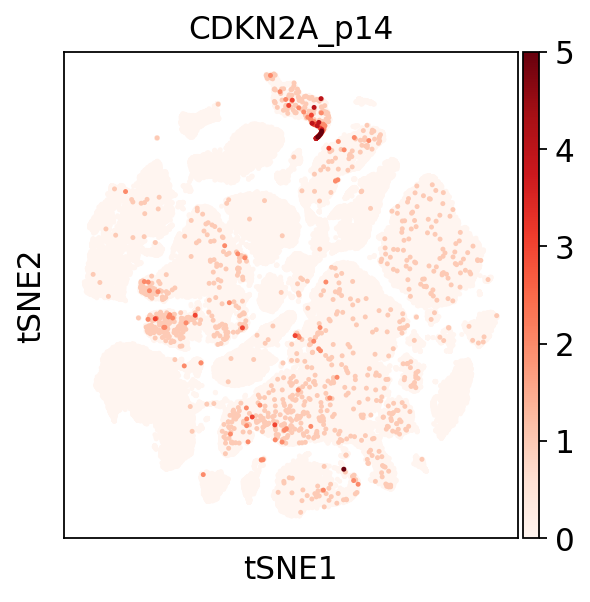

In [55]:
sc.pl.embedding(adata_filtered, basis='tsne', color='CDKN2A_p14', color_map='Reds', vmax='p99.995', size=20, use_raw=True, save='He_tSNE_p14_Raw_Counts_p99.995.pdf')

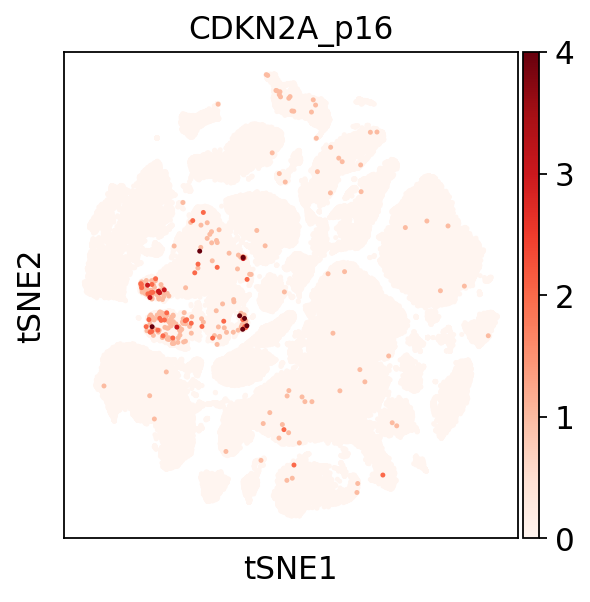

In [56]:
sc.pl.embedding(adata_filtered, basis='tsne', color='CDKN2A_p16', color_map='Reds', vmax='p99.995', size=20, use_raw=True, save='He_tSNE_p16_Raw_Counts_p99.995.pdf')

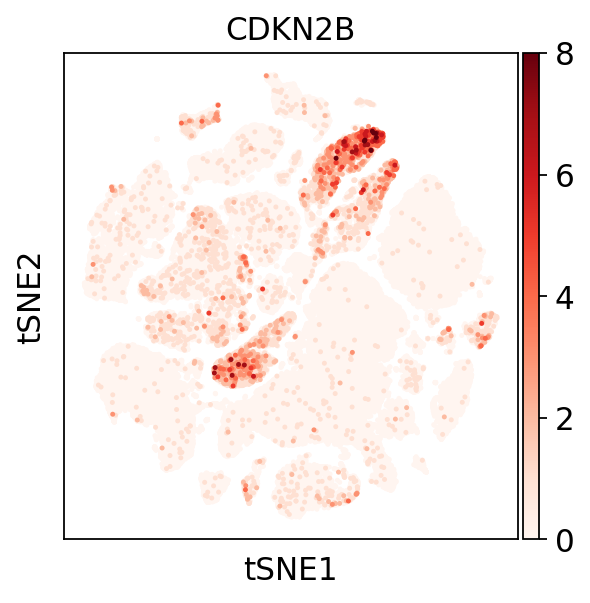

In [57]:
sc.pl.embedding(adata_filtered, basis='tsne', color='CDKN2B', color_map='Reds', vmax='p99.995', size=20, use_raw=True, save='He_tSNE_p15_Raw_Counts_p99.995.pdf')

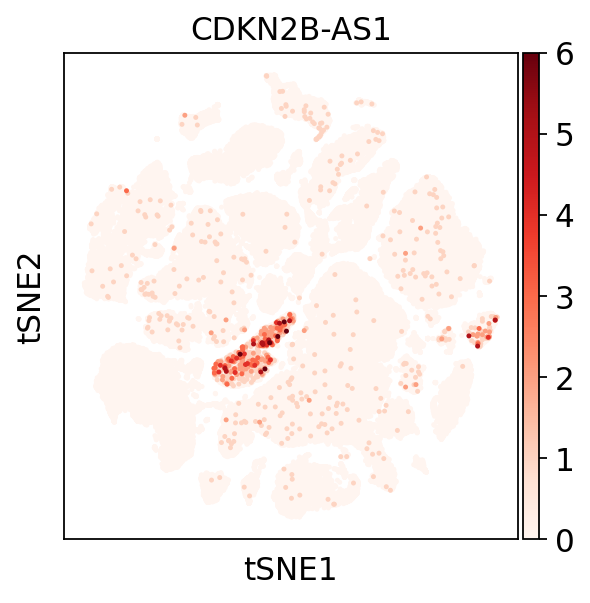

In [58]:
sc.pl.embedding(adata_filtered, basis='tsne', color='CDKN2B-AS1', color_map='Reds', vmax='p99.995', size=20, use_raw=True, save='He_tSNE_ANRIL_Raw_Counts_p99.995.pdf')

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


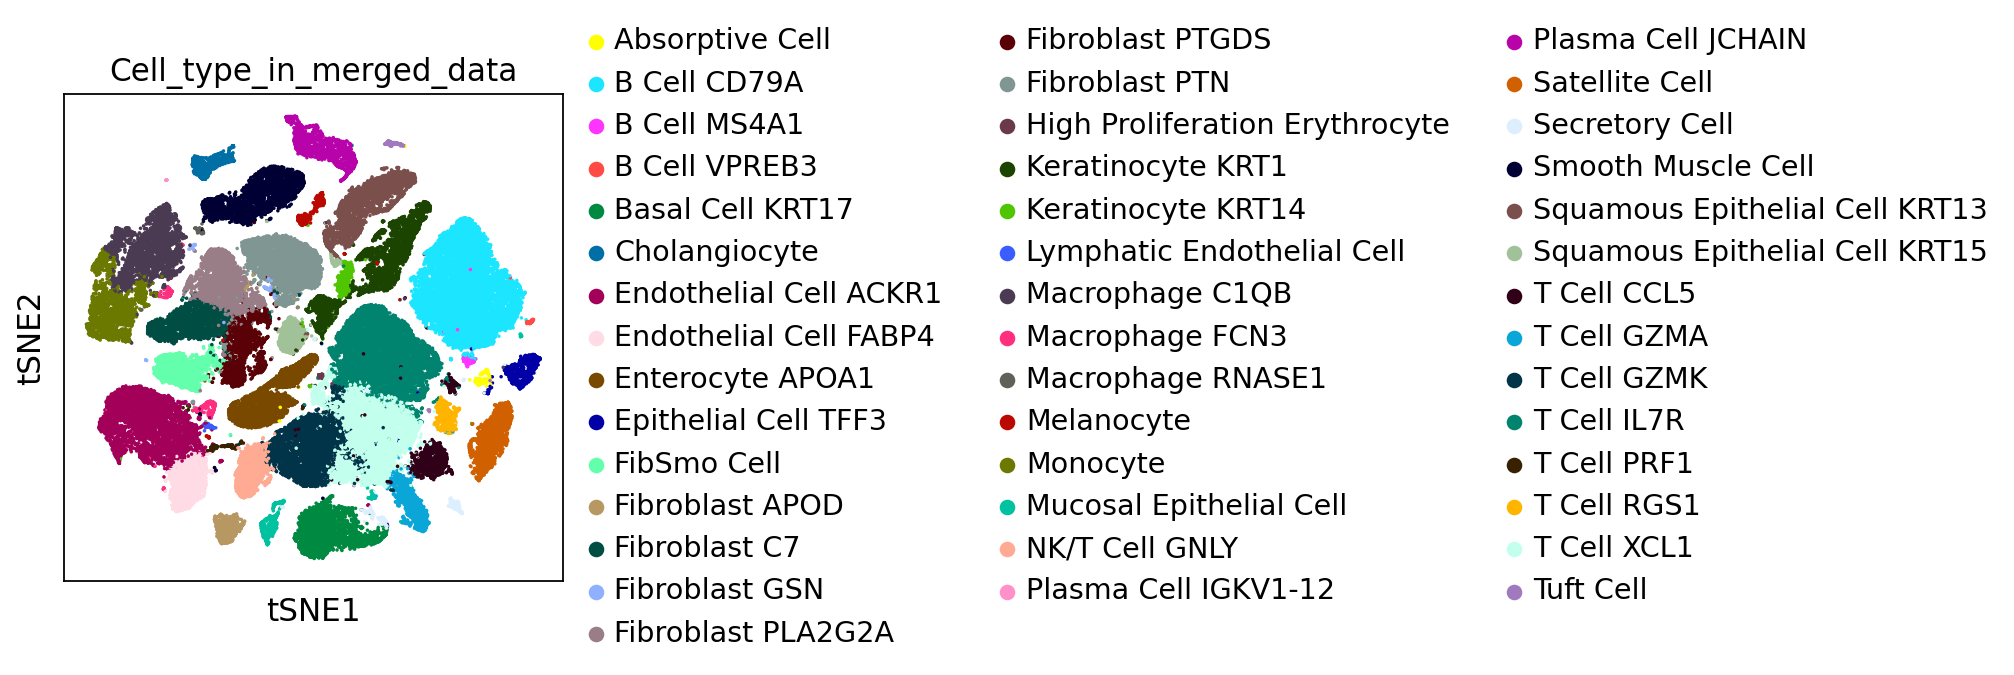

In [59]:
sc.pl.embedding(adata_filtered, basis='tsne', color='Cell_type_in_merged_data', size=10, save='He_tSNE_Cell_type_in_merged_data.pdf')

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


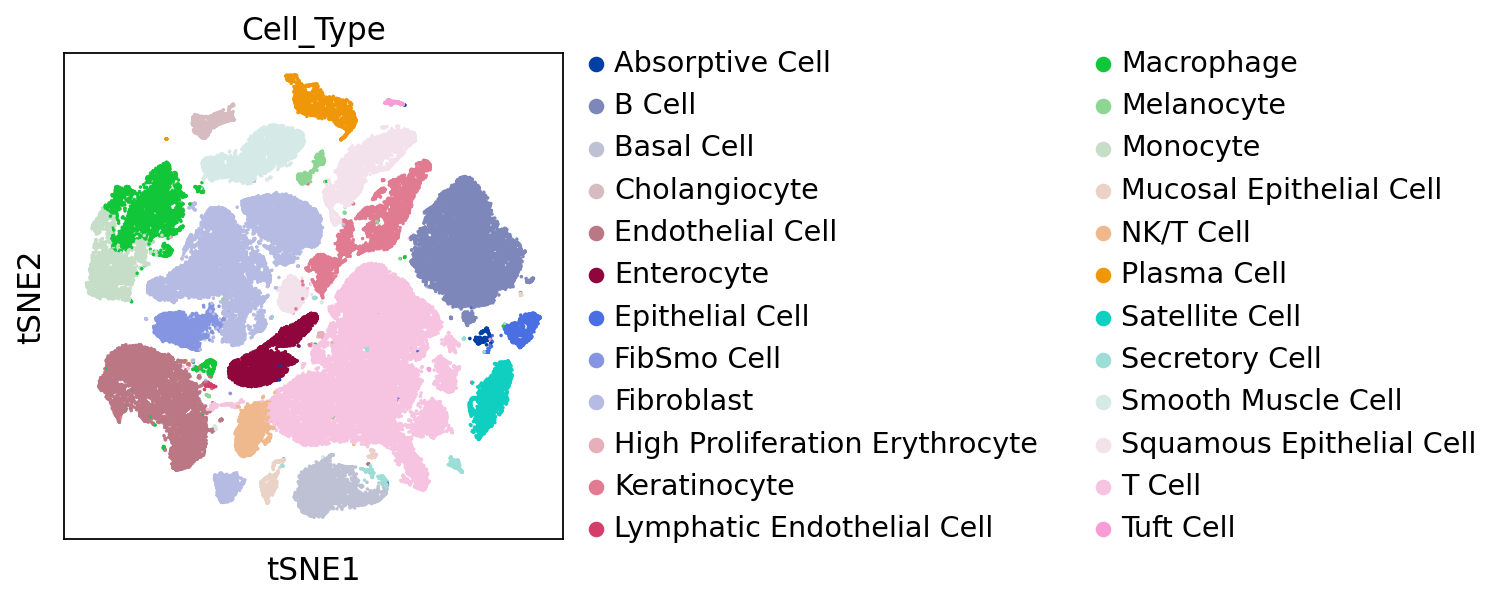

In [60]:
sc.pl.embedding(adata_filtered, basis='tsne', color='Cell_Type', size=10, save='He_tSNE_Cell_Type.pdf')

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


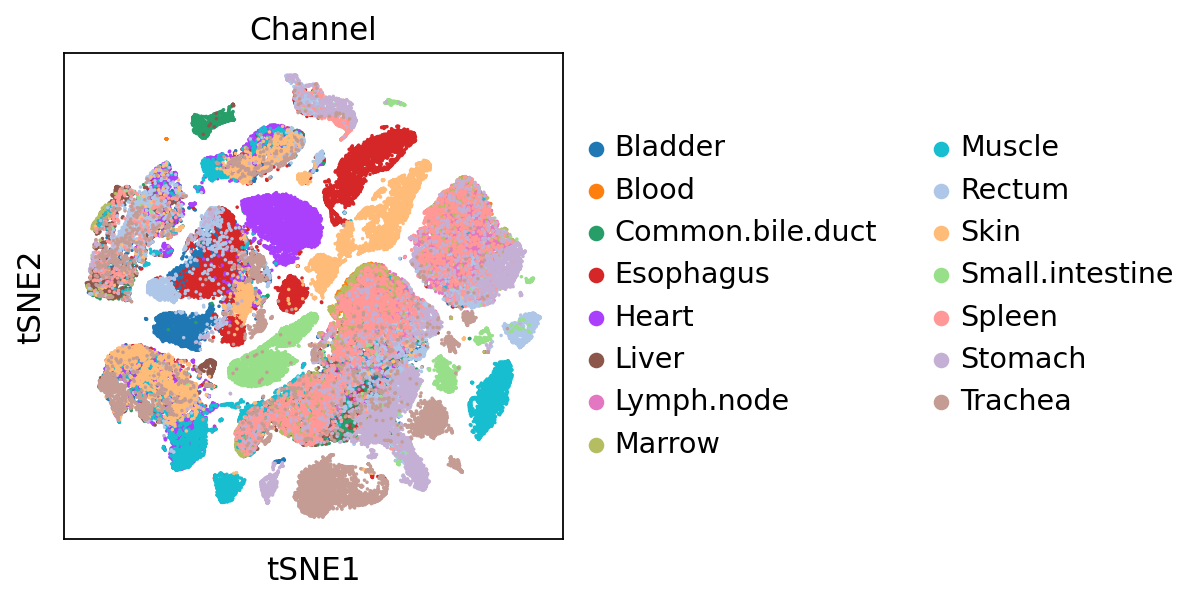

In [61]:
sc.pl.embedding(adata_filtered, basis='tsne', color='Channel', size=10, save='He_tSNE_Organ.pdf')